# ERA5 Time-Series Analysis: Anomaly Extraction & Quantile Regression

We use the monthly ERA5-Land total Precipitation (tp in m) dataset to perform some basic climate statistics for South America.

ERA5 land (https://www.ecmwf.int/en/era5-land) is a high-resolution dataset for several climatic variables. It is available 5 days before the current date. ERA5-Land provides hourly high-resolution information of surface variables. 

**We use totalPrecipitation (tp)**: https://www.dropbox.com/scl/fi/kvqtett1d5alnx9sc97wg/ERA5_land_SouthAmerica_totalPrecipitation_monthly.nc?rlkey=t7rz7y9vpu3caxqh1tqjr6gzn&st=r66g9222&dl=0

Additional data for South America:

**UW-Wind:** https://www.dropbox.com/scl/fi/39s3t29q8zs9gqvn7lurr/ERA5_land_SouthAmerica_UVwind_monthly.nc?rlkey=utnxnr7erlm361co6sae80t7q&st=zh3bn9fj&dl=0

**T2m dew temperature (for relative humidity calculation):** https://www.dropbox.com/scl/fi/8ffdv3dp3oys143l3ru4q/ERA5_land_SouthAmerica_tpdew_monthly.nc?rlkey=bri6bfwf0f2pz7ligex3mf9ez&st=kj6egw2w&dl=0


## Steps

1. **Load and Combine:** Use `xarray` to load a single file.
2. **De-seasononalize:** Calculate a daily rolling climatology and subtract it to isolate the climate anomaly signal.
3. **Mean Linear Regression:** Calculate the long-term trend of the mean signal.

In [1]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# Important note on data artefacts

The diagonal lines/anomalies typically appear due to the following reasons:

**Reduced Gaussian Grid Architecture:** The native spatial resolution of ERA5-Land (~9 km) uses a "reduced Gaussian grid" (TCo1279), where the number of grid points decreases towards the poles to prevent the clustering of data near the Arctic and Antarctic. When downloading data from the Copernicus Climate Data Store, the data is typically interpolated into a regular 0.1° × 0.1° latitude-longitude grid. This remapping process can introduce artificial diagonal lines and geometric artifacts, particularly in areas with sharp topological transitions.

**Spectral Truncation (Gibbs Phenomenon):** Because the meteorological models calculate climate variables using spectral harmonics, sharp geographical boundaries (like coastlines or steep mountain ranges) can cause "ringing" effects or wave-like patterns—creating diagonal lines that bleed outward from the terrain feature.

**Data Assimilation Adjustments:** While ERA5-Land itself does not directly assimilate observations, it is driven by atmospheric forcing from the parent ERA5 model. The assimilation of satellite swaths and unevenly spaced weather stations can create spatial discontinuities that leave faint linear or geometric "scars" across the map.

# Performing regression with xarray and dask

In [2]:
# Core parallel computing initialization
from dask.distributed import Client, LocalCluster
#The memory_limit keyword argument to LocalCluster sets the limit per worker.
cluster = LocalCluster(n_workers=6,
                       threads_per_worker=2,
                       memory_limit='4GB')
client = Client(cluster)
print(f"Dask dashboard active at: {client.dashboard_link}")

Dask dashboard active at: http://127.0.0.1:8787/status


In [3]:
# Load ERA5_daily_tp data
data_dir = "./"

file2load = os.path.join(data_dir, "ERA5_land_SouthAmerica_totalPrecipitation_monthly.nc")
ds = xr.open_mfdataset(file2load)
print(ds)

<xarray.Dataset> Size: 553MB
Dimensions:     (valid_time: 917, latitude: 501, longitude: 301)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
Data variables:
    tp          (valid_time, latitude, longitude) float32 553MB dask.array<chunksize=(230, 126, 76), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-14T08:03 GRIB to CDM+CF via cfgrib-0.9.1...


In [4]:
ds['tp']

<xarray.DataArray 'tp' (valid_time: 917, latitude: 501, longitude: 301)> Size: 553MB
dask.array<open_dataset-tp, shape=(917, 501, 301), dtype=float32, chunksize=(230, 126, 76), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      150801
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

## xarray: Watch your chunks!

**Make sure the data chunks are appropriate for your analysis.**

In [5]:
ds = ds.chunk({
    "valid_time": -1, 
    "latitude": 100, 
    "longitude": 100
})

In [6]:
ds['tp']

<xarray.DataArray 'tp' (valid_time: 917, latitude: 501, longitude: 301)> Size: 553MB
dask.array<rechunk-merge, shape=(917, 501, 301), dtype=float32, chunksize=(917, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      150801
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [7]:
tp_mean = ds.tp.mean(dim='valid_time')
print(tp_mean.shape)

(501, 301)


(Text(0.5, 1.0, 'Mean totalPrecipitation in mm/y'),
 <matplotlib.colorbar.Colorbar at 0x7f0a87760350>)

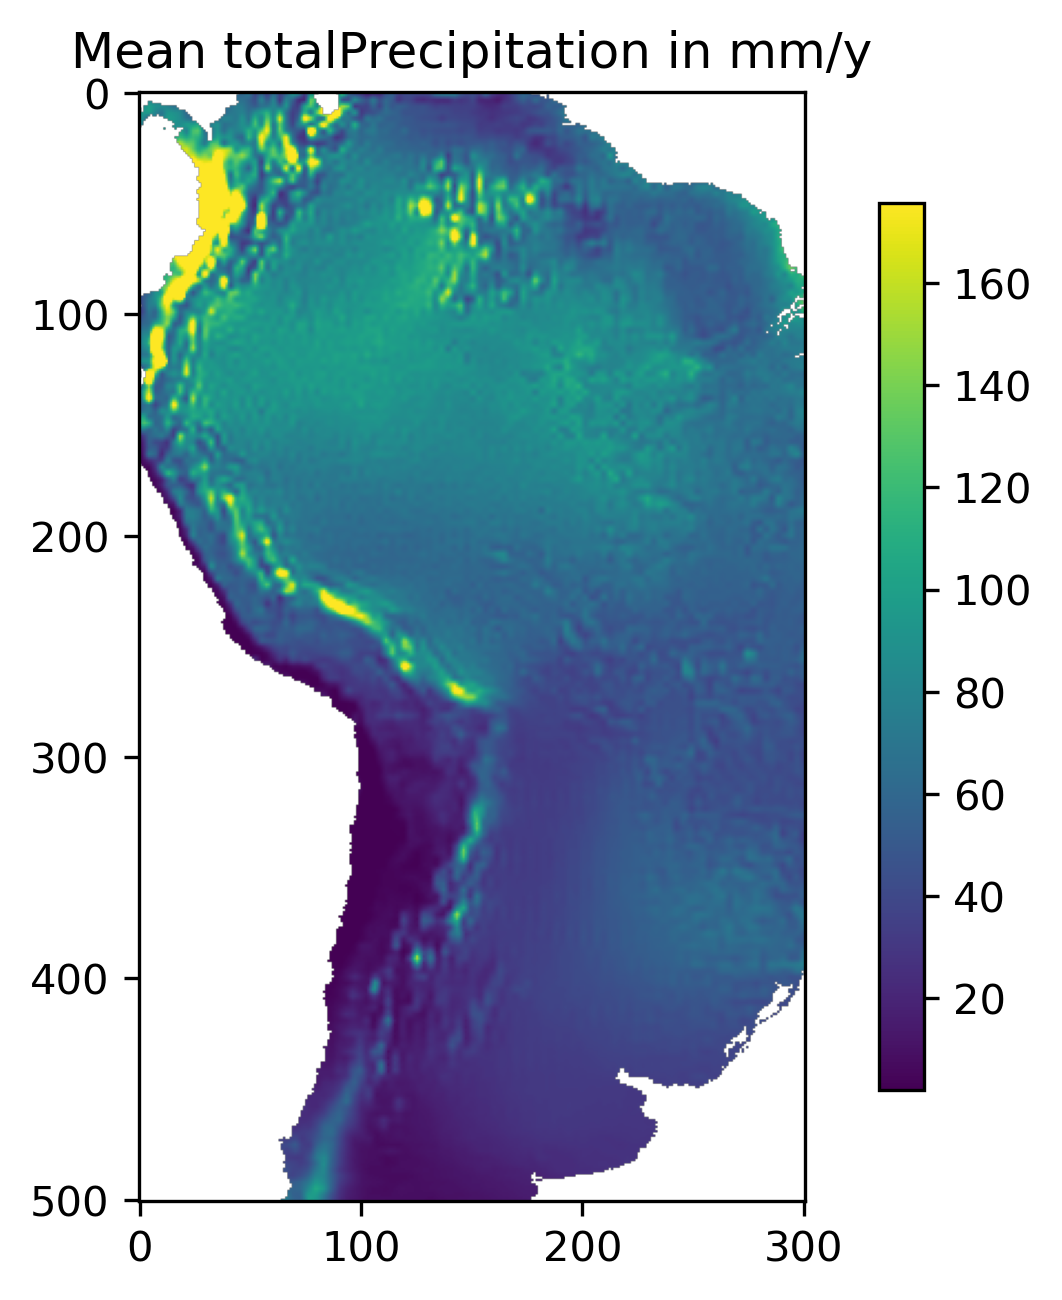

In [8]:
plt.imshow(tp_mean*12*1000, cmap='viridis', vmin=np.nanpercentile(tp_mean*12*1000, 1), vmax=np.nanpercentile(tp_mean*12*1000, 99))
plt.title('Mean totalPrecipitation in mm/y'), plt.colorbar(orientation='vertical', shrink=0.8)

## 1. Removing the Seasonal Signal (Building Climatology and Anomalies)

Climate trend analysis requires removing the predictable seasonal cycle (e.g., summer warming vs winter cooling) to see if the overall baseline is shifting. 

We accomplish this by grouping the data by the daily time variable, calculating the historical daily mean, and subtracting that mean curve from our original series. You could also do this monthly (provides smoother results)

In [9]:
climatology = ds.groupby("valid_time.month").mean("valid_time") # this is the monthly mean
anomalies = ds.groupby('valid_time.month') - climatology

In [10]:
anomalies['tp']

<xarray.DataArray 'tp' (valid_time: 917, latitude: 501, longitude: 301)> Size: 553MB
dask.array<sub, shape=(917, 501, 301), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      (valid_time) int64 7kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
    month       (valid_time) int64 7kB 1 2 3 4 5 6 7 8 9 ... 10 11 12 1 2 3 4 5

In [11]:
anomalies = anomalies.chunk({
    "valid_time": -1, 
    "latitude": 100, 
    "longitude": 100
})

In [12]:
anomalies['tp']

<xarray.DataArray 'tp' (valid_time: 917, latitude: 501, longitude: 301)> Size: 553MB
dask.array<rechunk-merge, shape=(917, 501, 301), dtype=float32, chunksize=(917, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      (valid_time) int64 7kB dask.array<chunksize=(917,), meta=np.ndarray>
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
    month       (valid_time) int64 7kB dask.array<chunksize=(917,), meta=np.ndarray>

In [13]:
# Remember: We have not yet computed anything!
anomalies.compute()

<xarray.Dataset> Size: 553MB
Dimensions:     (valid_time: 917, latitude: 501, longitude: 301)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      (valid_time) int64 7kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    expver      (valid_time) <U4 15kB '0001' '0001' '0001' ... '0005' '0005'
    month       (valid_time) int64 7kB 1 2 3 4 5 6 7 8 9 ... 10 11 12 1 2 3 4 5
Data variables:
    tp          (valid_time, latitude, longitude) float32 553MB nan nan ... nan

## 2. Linear Mean Trend Regression, p values, and r squared

Let's compute a standard Ordinary Least Squares (OLS) regression to check the trajectory of the average anomaly signal over time.

In [14]:
#verify chunks for anomalies!
anomalies['tp']

<xarray.DataArray 'tp' (valid_time: 917, latitude: 501, longitude: 301)> Size: 553MB
dask.array<rechunk-merge, shape=(917, 501, 301), dtype=float32, chunksize=(917, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2026-05-01
  * latitude    (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude   (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number      (valid_time) int64 7kB dask.array<chunksize=(917,), meta=np.ndarray>
    expver      (valid_time) <U4 15kB dask.array<chunksize=(917,), meta=np.ndarray>
    month       (valid_time) int64 7kB dask.array<chunksize=(917,), meta=np.ndarray>

In [15]:
# Just in case you need to rechunk:
anomalies = anomalies.chunk({
    "valid_time": -1, 
    "latitude": 100, 
    "longitude": 100
})

In [16]:
%%time
# This performs a statsmodel calculation for every pixel. This is not optimized and very slow! 
# But the chunking allows to process large datasets.

def statsmodels_single_pixel_all_metrics(y_pixel):
    """
    Returns a tuple of 3 scalar elements: (slope, p_value, r_squared)
    """
    if np.isnan(y_pixel).all():
        return np.nan, np.nan, np.nan
        
    try:
        n_time = len(y_pixel)
        pixel_timeline = np.arange(n_time, dtype=float)
        
        valid_mask = ~np.isnan(y_pixel)
        X_clean = pixel_timeline[valid_mask]
        y_clean = y_pixel[valid_mask]
        
        if len(y_clean) < 3:
            return np.nan, np.nan, np.nan
            
        X_matrix = sm.add_constant(X_clean)
        model = sm.OLS(y_clean, X_matrix)
        results = model.fit()
        
        return float(results.params[1]), float(results.pvalues[1]), float(results.rsquared)
    except Exception:
        return np.nan, np.nan, np.nan


# Apply across your dataset returning a tuple of three distinct maps
slope, p_value, r_squared = xr.apply_ufunc(
    statsmodels_single_pixel_all_metrics,
    anomalies,
    input_core_dims=[["valid_time"]],
    output_core_dims=[[], [], []], # Enforce 1 scalar output for each returned item
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float]
)

# Call compute on whichever map you want to load into memory
slope_final = slope.compute() * 120 * 10000
p_value_final = p_value.compute()
r_squared_final = r_squared.compute()

CPU times: user 1min 54s, sys: 3.13 s, total: 1min 57s
Wall time: 2min 26s


### Visualize Results in map views

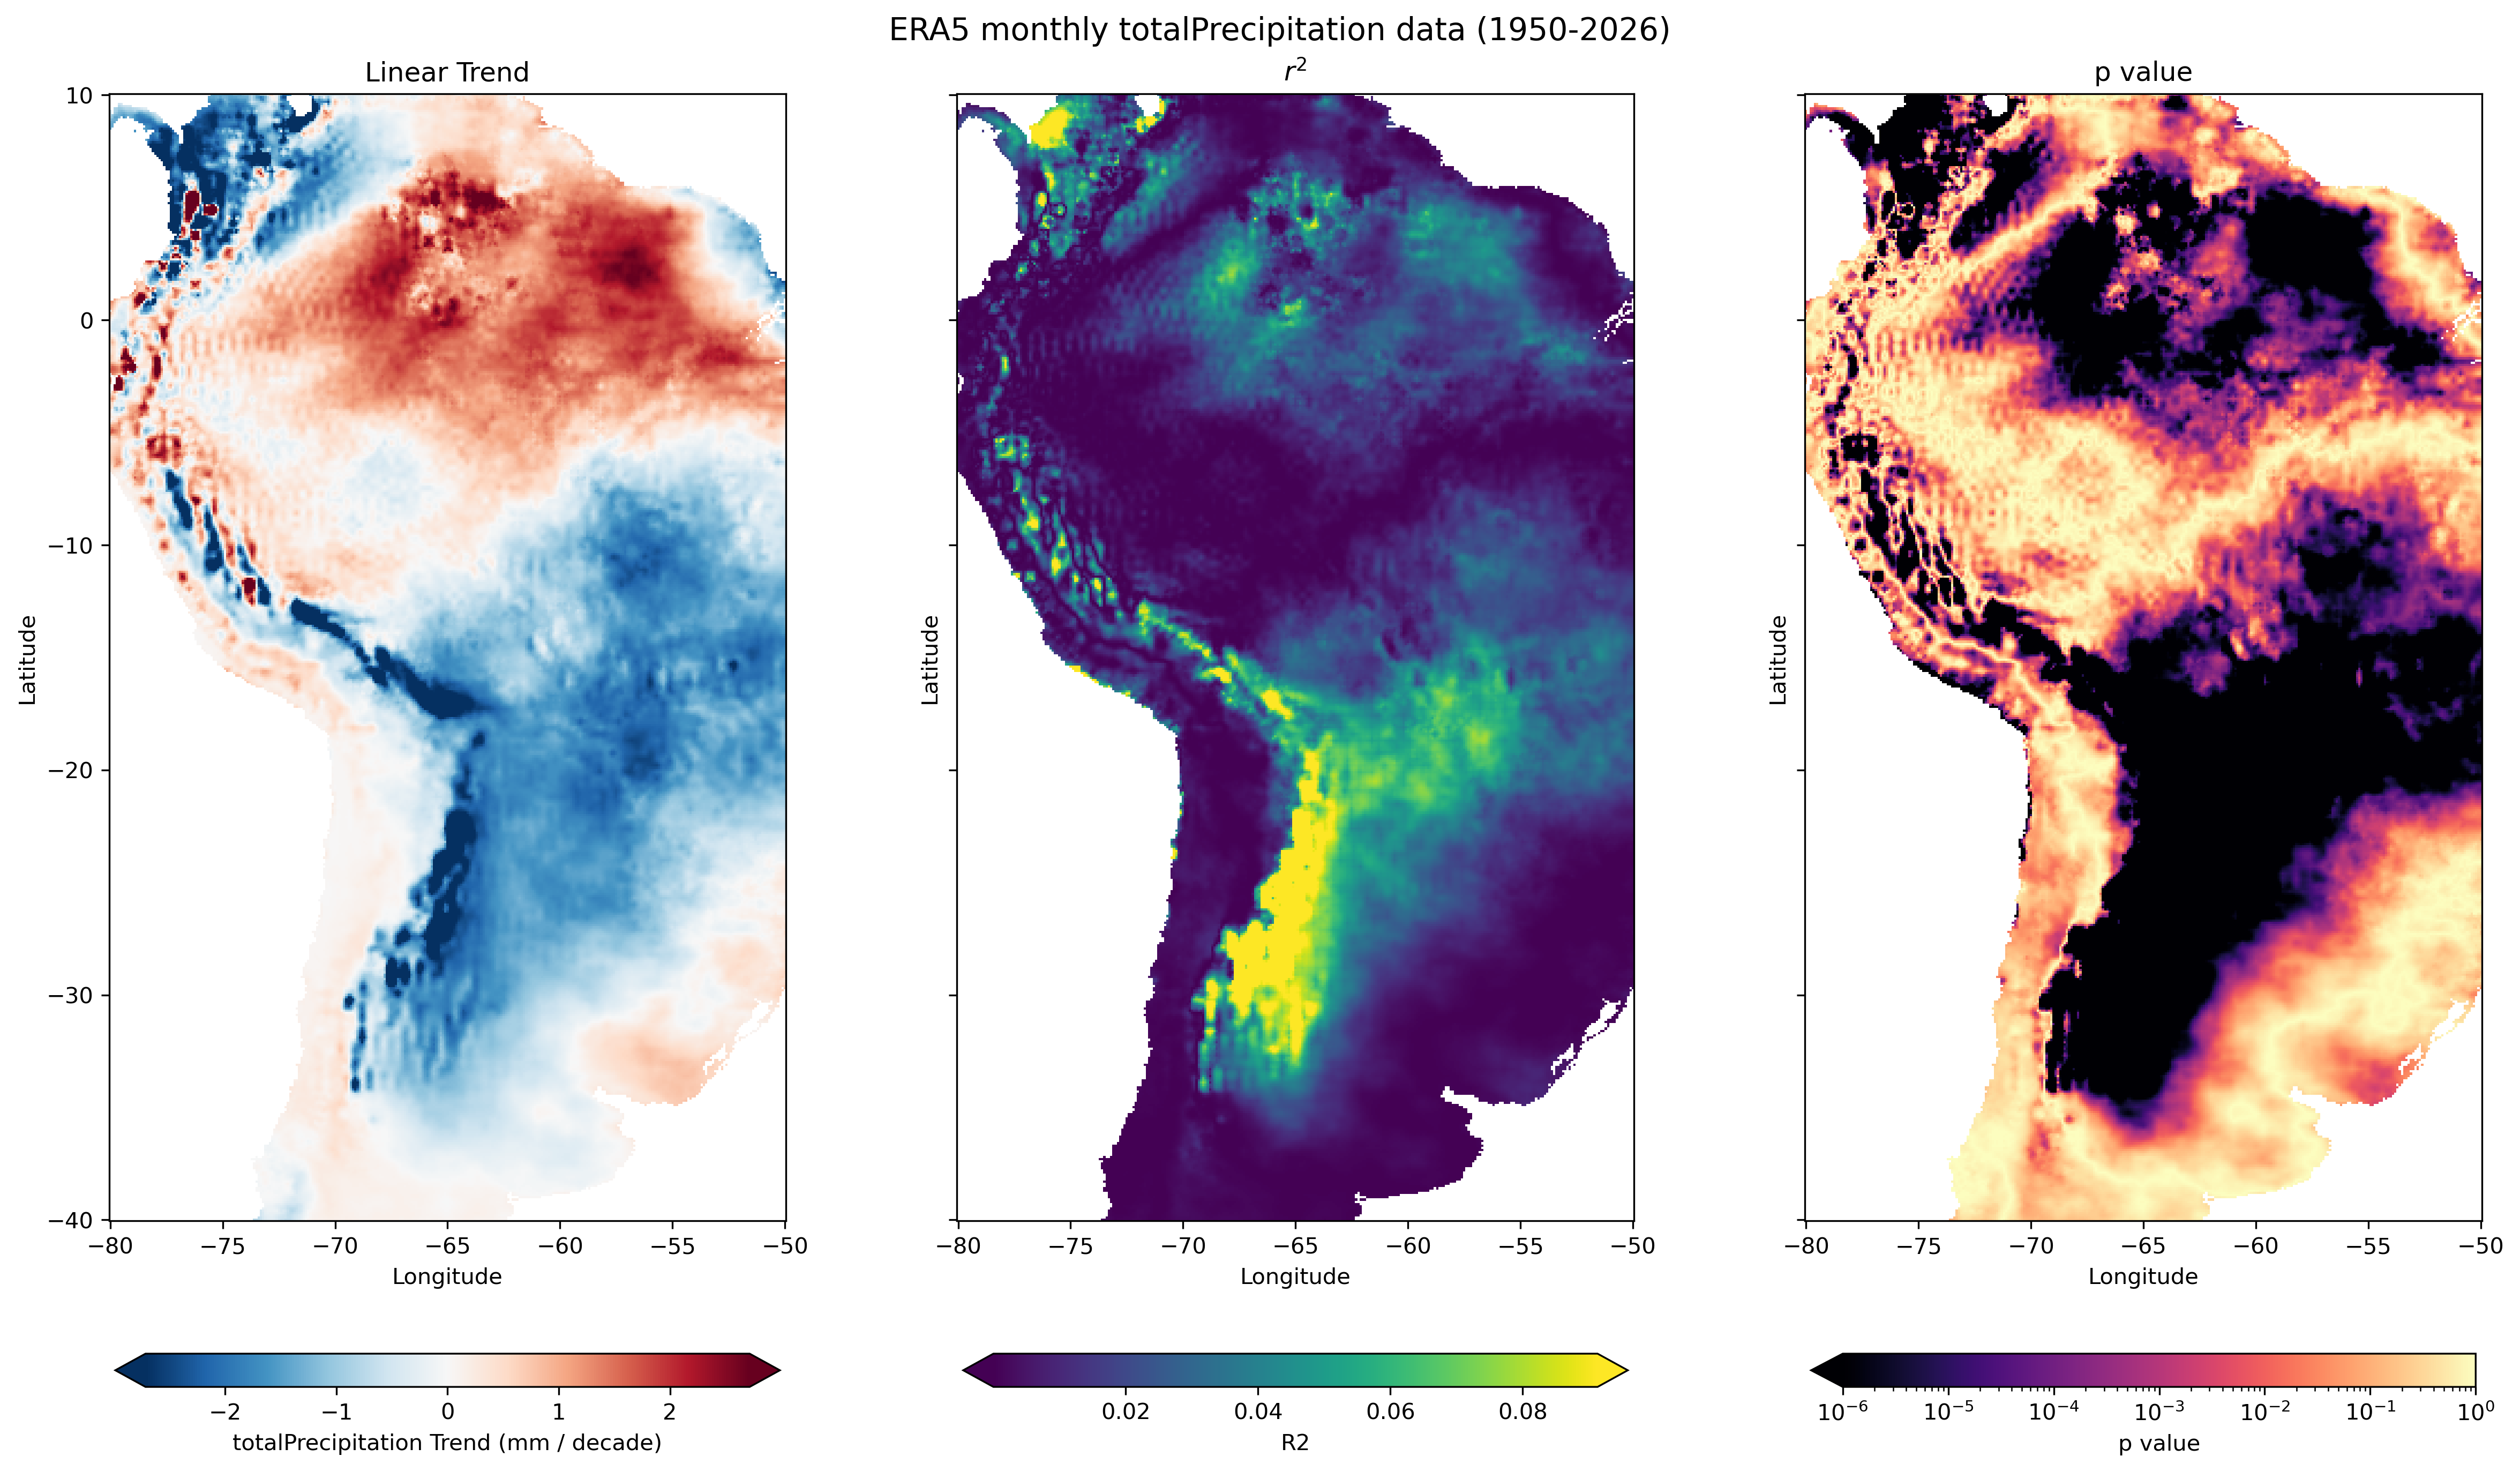

In [17]:
# Make a figure showing all attributes
import matplotlib.colors as colors

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,9), sharey=True, dpi=300, layout='constrained')

slope_final['tp'].plot(
    cmap="RdBu_r", 
    robust=True, 
    cbar_kwargs={"label": "totalPrecipitation Trend (mm / decade)", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[0]
)
ax[0].set_title("Linear Trend", fontsize=12)
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_aspect('equal')

r_squared_final['tp'].plot(
    cmap="viridis", 
    robust=True, 
    cbar_kwargs={"label": "R2", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[1]
)
ax[1].set_title(r"$r^2$", fontsize=12)
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].set_aspect('equal')

p_value_final['tp'].plot(
    cmap="magma", 
    robust=True,
    norm=colors.LogNorm(vmin=1e-6, vmax=1),
    cbar_kwargs={"label": "p value", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[2]
)
ax[2].set_title(r"p value", fontsize=12)
ax[2].set_xlabel("Longitude")
ax[2].set_ylabel("Latitude")
ax[2].set_aspect('equal')

fig.suptitle('ERA5 monthly totalPrecipitation data (1950-2026)', fontsize=14)
fig.savefig('ERA5_monthly_totalPrecipitation_trends.png', dpi=300)

## 3. **OPTIONAL:** Save xarray data as geotiff and shapefile

First, we should combine the results into one netcdf file. For this to work, we need to properly label variables

In [18]:
slope_final

<xarray.Dataset> Size: 1MB
Dimensions:    (latitude: 501, longitude: 301)
Coordinates:
  * latitude   (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
Data variables:
    tp         (latitude, longitude) float64 1MB nan nan nan nan ... nan nan nan

In [19]:
slope_final = slope_final.rename_vars({"tp": "tp_trend_per_decade"})
r_squared_final = r_squared_final.rename_vars({"tp": "rsquared"})
p_value_final = p_value_final.rename_vars({"tp": "p_value"})

In [20]:
ds_combined = xr.merge([slope_final, r_squared_final, p_value_final])

# # Add metadata attributes to the file (optional but recommended)
ds_combined.attrs["description"] = "Combined ERA5 Land regression results"
ds_combined["tp_trend_per_decade"].attrs["units"] = "mm/decade"  # or "°C" depending on your data
ds_combined["tp_trend_per_decade"].attrs["long_name"] = "totalPrecipitation trend per decade"

ds_combined.attrs["title"] = "Consolidated ERA5 regression results for South America"
ds_combined.attrs["institution"] = "University of Potsdam"
ds_combined.attrs["history"] = "Merged and metadata annotated using Xarray pipeline"
ds_combined.attrs["references"] = "Conforms to NetCDF CF Metadata Conventions"

# Export directly to a single NetCDF file
# ds_combined.to_netcdf("ERA5_land_tp_regression_results.nc")

In [21]:
ds_combined

<xarray.Dataset> Size: 4MB
Dimensions:              (latitude: 501, longitude: 301)
Coordinates:
  * latitude             (latitude) float64 4kB 10.0 9.9 9.8 ... -39.9 -40.0
  * longitude            (longitude) float64 2kB -80.0 -79.9 ... -50.1 -50.0
Data variables:
    tp_trend_per_decade  (latitude, longitude) float64 1MB nan nan ... nan nan
    rsquared             (latitude, longitude) float64 1MB nan nan ... nan nan
    p_value              (latitude, longitude) float64 1MB nan nan ... nan nan
Attributes:
    description:  Combined ERA5 Land regression results
    title:        Consolidated ERA5 regression results for South America
    institution:  University of Potsdam
    history:      Merged and metadata annotated using Xarray pipeline
    references:   Conforms to NetCDF CF Metadata Conventions

In [22]:
import geopandas as gpd

def save_xarray_as_geotiff(da, da_name, output_filename="output.tif"):
    """Prepares and saves a 2D xarray DataArray as a GeoTIFF file."""
    # 1. rioxarray requires specific dimension names ('x' and 'y').
    # Rename your dimensions if they are called 'longitude'/'latitude' or 'lon'/'lat'
    rename_dict = {}
    if "longitude" in da.dims:
        rename_dict["longitude"] = "x"
    elif "lon" in da.dims:
        rename_dict["lon"] = "x"

    if "latitude" in da.dims:
        rename_dict["latitude"] = "y"
    elif "lat" in da.dims:
        rename_dict["lat"] = "y"

    if rename_dict:
        da = da.rename(rename_dict)
    # 2. Ensure the DataArray has spatial coordinates properly indexed for rioxarray
    # (This tells rioxarray which dimensions represent the spatial grid)
    da = da.rio.set_spatial_dims(x_dim="x", y_dim="y")
    # 3. Assign a Coordinate Reference System (CRS).
    # ERA5 and most global climate models use unprojected WGS84 (EPSG:4326).
    da = da.rio.write_crs("EPSG:4326")
    # 4. Export to GeoTIFF
    da[da_name].rio.to_raster(output_filename)


def save_trend_as_shapefile(ds_trend, p_threshold=0, output_shapefile="trends.shp"):
    """Converts a 2D spatial Xarray Dataset containing 'slope' and 'p_value'

    into a GIS-ready Shapefile using GeoPandas only.
    """

    # 1. Automatically detect dimension names (handling lat/lon or latitude/longitude)
    lon_name = "longitude" if "longitude" in ds_trend.dims else "lon"
    lat_name = "latitude" if "latitude" in ds_trend.dims else "lat"

    if lon_name not in ds_trend.dims or lat_name not in ds_trend.dims:
        raise KeyError(
            f"Could not find spatial dimensions. Found: {list(ds_trend.dims)}"
        )

    # 2. Flatten the 2D grid dimensions into 1D arrays
    lon_flat = ds_trend[lon_name].values
    lat_flat = ds_trend[lat_name].values

    # Create a 2D meshgrid of coordinates, then flatten to 1D
    lon_mesh, lat_mesh = np.meshgrid(lon_flat, lat_flat)
    lon_coords = lon_mesh.ravel()
    lat_coords = lat_mesh.ravel()

    # Flatten our data variables
    slopes_flat = ds_trend["tp_trend_per_decade"].values.ravel()
    pvals_flat = ds_trend["p_value"].values.ravel()
    rsquared_flat = ds_trend["rsquared"].values.ravel()

    # 3. Filter out NaN values (e.g., ocean masks)
    valid_mask = ~np.isnan(slopes_flat)

    lon_coords = lon_coords[valid_mask]
    lat_coords = lat_coords[valid_mask]
    slopes_flat = slopes_flat[valid_mask]
    pvals_flat = pvals_flat[valid_mask]
    rsquared_flat = rsquared_flat[valid_mask]

    # 4. Filter by p value
    if p_threshold > 0:
        valid_mask = pvals_flat <= p_threshold
        lon_coords = lon_coords[valid_mask]
        lat_coords = lat_coords[valid_mask]
        slopes_flat = slopes_flat[valid_mask]
        pvals_flat = pvals_flat[valid_mask]
        rsquared_flat = rsquared_flat[valid_mask]

    # 4. Prepare data dictionary (respecting Shapefile 10-char header limit)
    data_dict = {"slope": slopes_flat, "p_value": pvals_flat, 'rsquared': rsquared_flat}

    # 5. Use geopandas.points_from_xy directly for geometry generation
    print(f"Generating vector geometry for {len(slopes_flat)} pixels...")
    geometry = gpd.points_from_xy(lon_coords, lat_coords)
    # 6. Build the GeoDataFrame (WGS84 / EPSG:4326)
    gdf = gpd.GeoDataFrame(data_dict, geometry=geometry, crs="EPSG:4326")

    # 7. Write to disk
    print(f"Writing vector data to {output_shapefile}...")
    gdf.to_file(output_shapefile)
    print("Export complete!")
    return gdf


In [23]:
# save trend as geotiff
save_xarray_as_geotiff(ds_combined, 'tp_trend_per_decade', output_filename="ERA5_land_tp_trend_decade.tif")

In [24]:
# save data as geopackage vector file
save_trend_as_shapefile(ds_combined, p_threshold=0.05, output_shapefile="ERA5_land_tp_trend_decade_pvalue005.shp")

Generating vector geometry for 72829 pixels...
Writing vector data to ERA5_land_tp_trend_decade_pvalue005.shp...
Export complete!


,slope,p_value,rsquared,geometry
0,-1.365878,1.490154e-07,0.029732,POINT (-75.5 10)
1,-1.384407,4.564728e-09,0.036882,POINT (-75.4 10)
2,-1.369359,7.045520e-09,0.035993,POINT (-75.3 10)
3,-1.333226,1.128904e-07,0.030302,POINT (-75.2 10)
4,-1.341475,6.774856e-07,0.026624,POINT (-75.1 10)
...,...,...,...,...
72824,0.215320,3.858776e-02,0.004668,POINT (-69.1 -37.9)
72825,0.206977,3.623825e-02,0.004784,POINT (-69.2 -38)
72826,0.194059,4.599266e-02,0.004345,POINT (-69.1 -38)
72827,0.179122,4.646651e-02,0.004326,POINT (-68.8 -38.1)


# Next steps:

Express trend as percentage of total Precipitation

In [26]:
client.close()
cluster.close()